# Congrats! Now we are ready to train the model with the full dataset

# Step 2
Now that our model works for 1 and 10 images relatively reliable, we can see how it performs on the full dataset.

### Step 2.1
First, let's import everything we need again and set up the project just as we did in 01_exploration.ipnyb


In [19]:
import torch
import matplotlib.pyplot as plt

import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))

from src.dataset import CocoSegDataset
from src.model import UNet

# Flag for using CUDA by default if available.
# For debugging or in case of unexpected errors change it to False
USE_CUDA_ARG = True

Checking image and mask shapes

In [20]:
dataset = CocoSegDataset(
    image_dir="../data/train/images",
    json_path="../data/train/train.json"
)

img, mask = dataset[0]
print(img.shape)   # (3, H, W)
print(mask.shape)  # (1, H, W)
print(mask.max())


torch.Size([3, 160, 160])
torch.Size([1, 160, 160])
tensor(1.)


### Step 2.2 - Start the training

Note that we run the training with bigger batch size, but fewer epochs. Bigger batch size is not automatically better, depends on multiple factors and your hardware. [Read more about it here](https://eureka.patsnap.com/article/what-happens-if-batch-size-is-too-small-or-too-large)

For now, we just need to see the tendency of changes in loss.

Reference training times: <br>
**Intel Core i7-12700H:** est. ~3h <br>
**NVIDIA GeForce RTX 3060 (Laptop) GPU 6GB:** ~10m

In [21]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0), "" if USE_CUDA_ARG else "available, but using CPU now")
print("Training is running...")

%run -i ../src/train.py --train_range 0 --batch_size 8 --num_epochs 10 --use_cuda $USE_CUDA_ARG

True
NVIDIA GeForce RTX 3060 Laptop GPU 
Training is running...
Value of use_cuda is now  True
Running training with train_range= 0 , batch_size= 8 , num_epochs= 10 .
Using device:  cuda
Epoch [1/10] | train_loss: 0.0584 | val_loss: 0.0217 | train_iou: 0.1187 | val_iou: 0.7608
Saved best LOSS model
Saved best IoU model
Epoch [2/10] | train_loss: 0.0200 | val_loss: 0.0160 | train_iou: 0.1313 | val_iou: 0.7608
Saved best LOSS model
Epoch [3/10] | train_loss: 0.0174 | val_loss: 0.0161 | train_iou: 0.1205 | val_iou: 0.7608
Epoch [4/10] | train_loss: 0.0152 | val_loss: 0.0122 | train_iou: 0.2543 | val_iou: 0.5017
Saved best LOSS model
Saved best IoU model
Epoch [5/10] | train_loss: 0.0146 | val_loss: 0.0128 | train_iou: 0.3083 | val_iou: 0.4249
Saved best IoU model
Epoch [6/10] | train_loss: 0.0126 | val_loss: 0.0144 | train_iou: 0.3777 | val_iou: 0.5316
Epoch [7/10] | train_loss: 0.0112 | val_loss: 0.0093 | train_iou: 0.4007 | val_iou: 0.5641
Saved best LOSS model
Epoch [8/10] | train_loss

### Step 1.2 - Visualization of the data
In this step, we will take an actual look at what we just achieved.
First, let's see the original data from the dataset

In [22]:
image_dir = PROJECT_ROOT / "data" / "train" / "images"
json_path = PROJECT_ROOT / "data" / "train" / "train.json"

dataset = CocoSegDataset(
    image_dir = str(image_dir),
    json_path = str(json_path)
)

print ("Dataset size: ", len(dataset))

Dataset size:  3177


In [23]:
device = torch.device("cuda" if torch.cuda.is_available() and USE_CUDA_ARG else "cpu")

# loading our model to the device
model = UNet().to(device)

# loading our best model
checkpoint_path = PROJECT_ROOT / "checkpoints" / "best_loss_model.pth"
model.load_state_dict(torch.load(checkpoint_path, map_location=device))

# evaluation
model.eval()

print("Loaded model from: ", checkpoint_path)

Loaded model from:  D:\_LEARN\_ComputerVision\Kaggle\Segmentation-Lidar\segment-vehicle-lidar\checkpoints\best_loss_model.pth


C:\Users\slajcho\AppData\Local\Temp\ipykernel_54348\4095111191.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_path, map_loca

In [26]:
def predict_image(model, image, device, threshold):
    model.eval()
    with torch.no_grad():
        input_image = image.unsqueeze(0).to(device)
        logits = model(input_image)

        # we apply sigmoid here and not baked in the model.
        # The output of the model is raw logits.
        # This is because we use BCEWithLogitsLoss loss function. As the name suggests, it works with Logits, not with probabilities
        # Please refer to the PyTorch documentation: https://docs.pytorch.org/docs/2.12/generated/torch.nn.BCEWithLogitsLoss.html
        probs = torch.sigmoid(logits)
        pred_mask = (probs > threshold).float()
    return pred_mask, probs

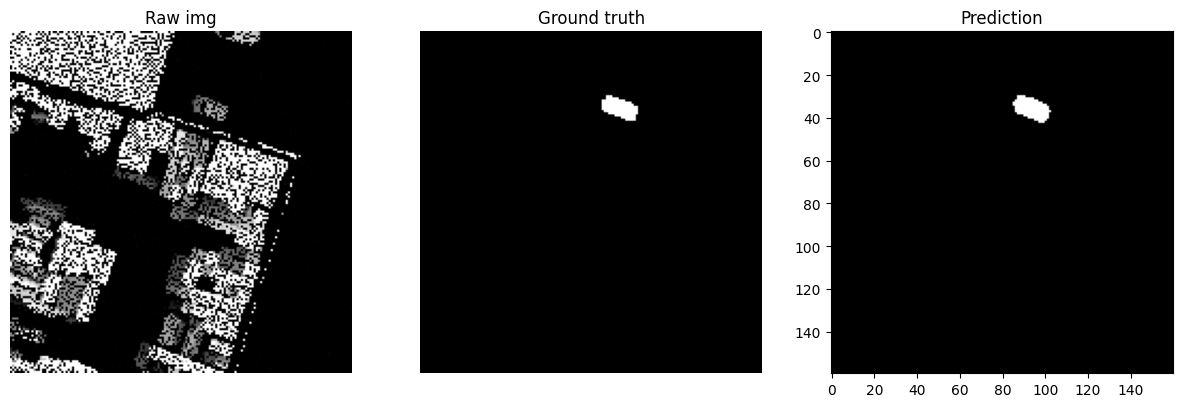

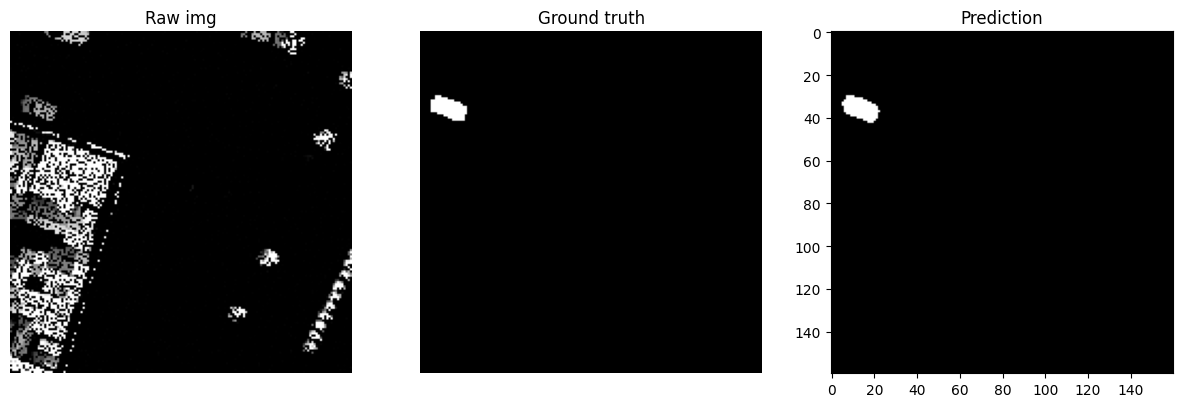

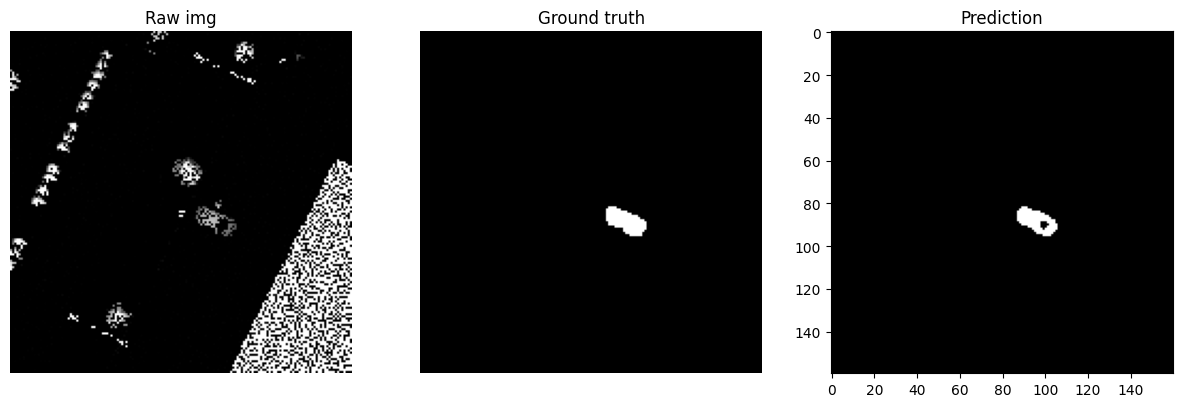

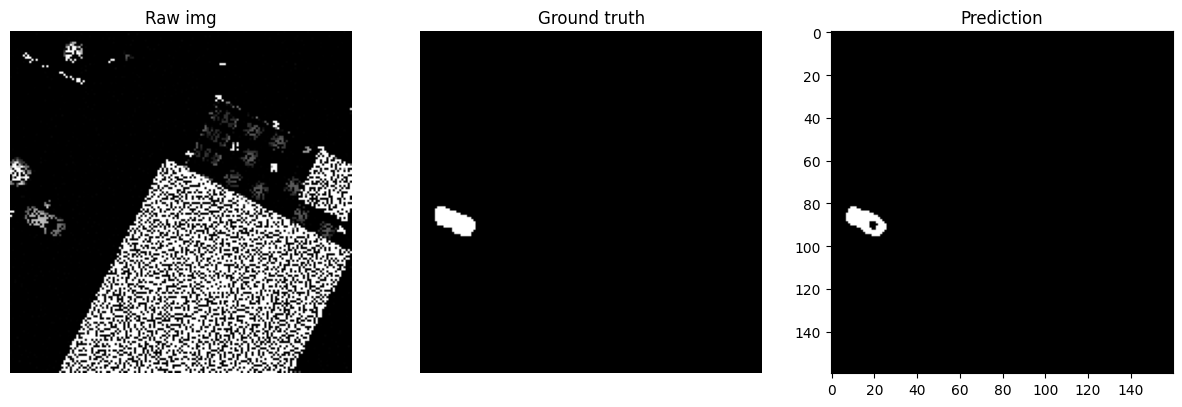

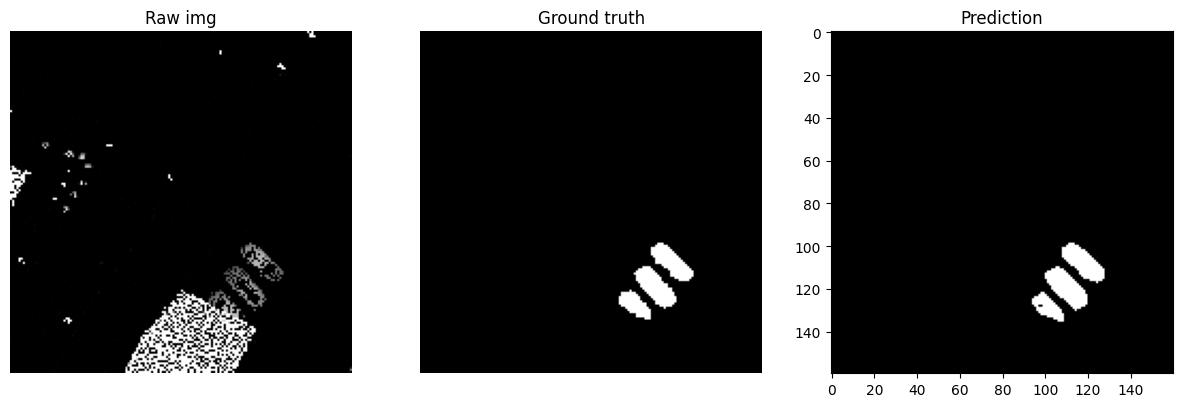

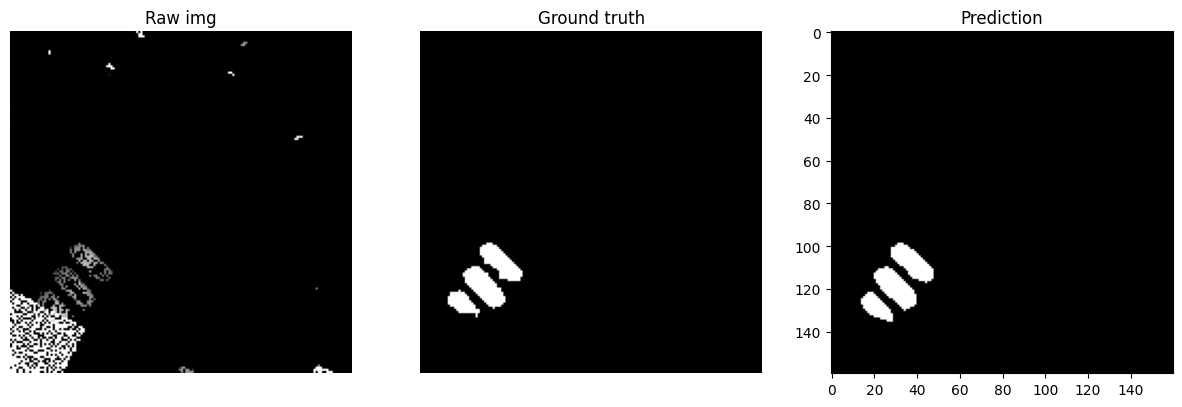

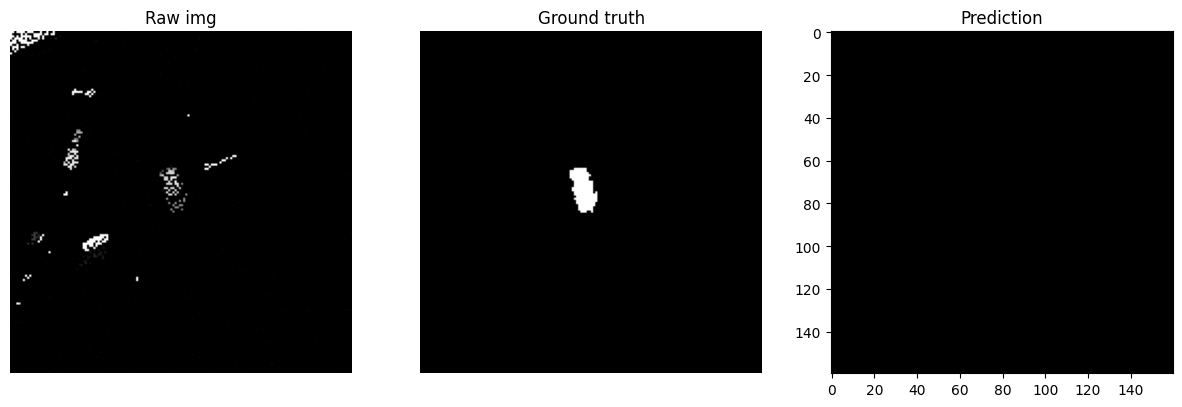

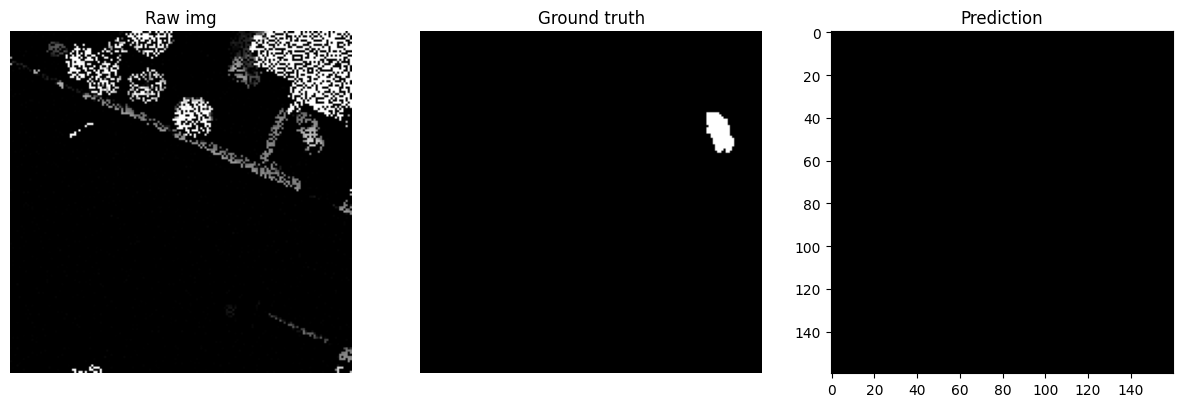

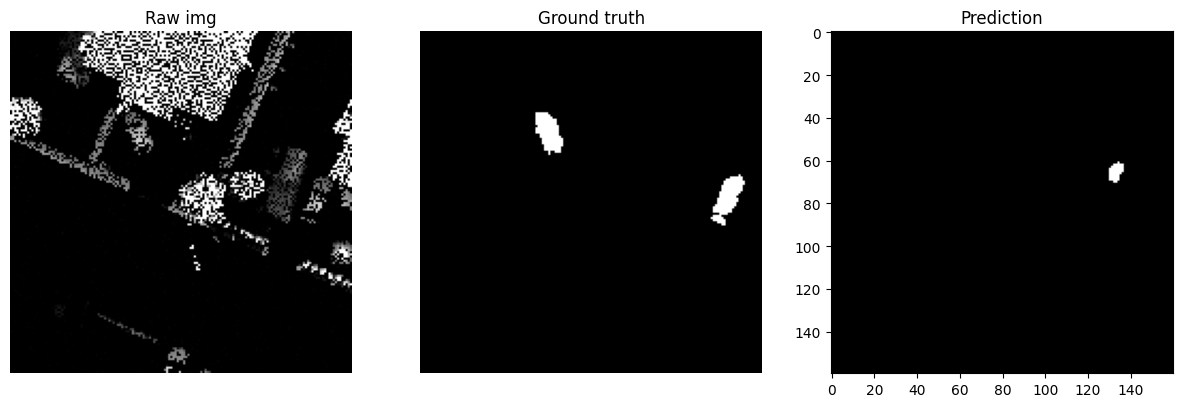

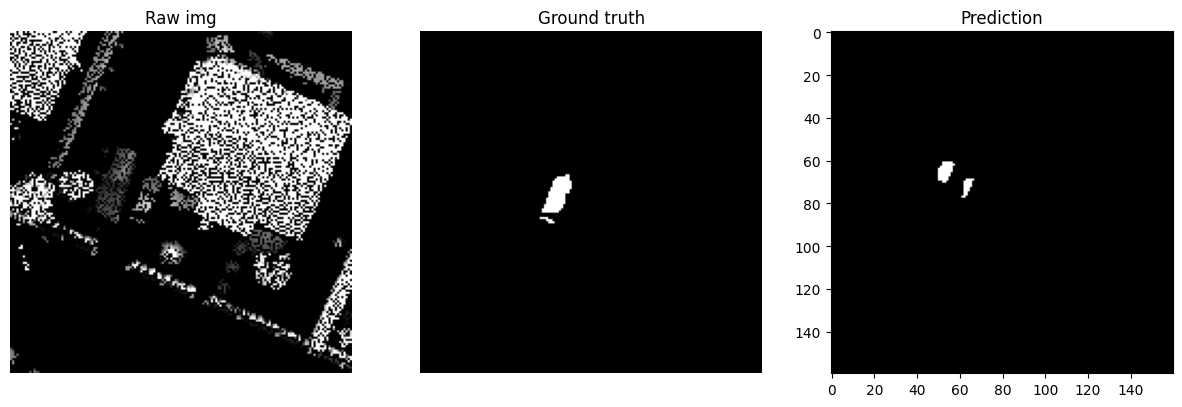

In [32]:
for idx in range(10):
    image, mask = dataset[idx]
    pred_mask, probs = predict_image(model, image, device, 0.5)
    pred_np = pred_mask.squeeze().cpu().numpy()

    plt.figure(figsize=(15,55))

    plt.subplot(idx+1,3,1)
    plt.title("Raw img")
    plt.imshow(image.permute(1,2,0))
    plt.axis("off")

    plt.subplot(idx+1,3,2)
    plt.title("Ground truth")
    plt.imshow(mask.squeeze(), cmap="gray")
    plt.axis("off")

    plt.subplot(idx+1,3,3)
    plt.title("Prediction")
    plt.imshow(pred_np, cmap="gray")

    plt.show()